# Automatic Differentiation — Theory Notebook

> *"Differentiating programs, not formulas — that is the key insight that makes modern deep learning possible."*

Interactive derivations: dual numbers from scratch, reverse-mode AD, JVP/VJP, higher-order derivatives, gradient checkpointing, custom autograd, and meta-learning gradients.

**Run cells top-to-bottom.** Each section builds on the previous.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="colorblind")
    HAS_SNS = True
except ImportError:
    plt.style.use("seaborn-v0_8-whitegrid")
    HAS_SNS = False

mpl.rcParams.update({
    "figure.figsize":    (10, 6),
    "figure.dpi":         120,
    "font.size":           13,
    "axes.titlesize":      15,
    "axes.labelsize":      13,
    "xtick.labelsize":     11,
    "ytick.labelsize":     11,
    "legend.fontsize":     11,
    "legend.framealpha":   0.85,
    "lines.linewidth":      2.0,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "savefig.bbox":       "tight",
    "savefig.dpi":         150,
})
np.random.seed(42)
print("Plot setup complete.")

torch not available — torch cells will be skipped
Setup complete.
  NumPy: 2.4.3
  Matplotlib: True
  PyTorch: False


In [ ]:
import numpy as np
import numpy.linalg as la
from scipy import optimize, special, stats
from scipy.optimize import minimize, fsolve, linprog
from math import factorial
import math
import matplotlib.patches as patches

COLORS = {
    "primary": "#0077BB",
    "secondary": "#EE7733",
    "tertiary": "#009988",
    "error": "#CC3311",
    "neutral": "#555555",
    "highlight": "#EE3377",
}
HAS_MPL = True
np.set_printoptions(precision=8, suppress=True)
np.random.seed(42)
spmin = minimize

try:
    import torch
    HAS_TORCH = True
except ImportError:
    torch = None
    HAS_TORCH = False


def header(title):
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))

def check_true(name, cond):
    ok = bool(cond)
    print(f"{'PASS' if ok else 'FAIL'} - {name}")
    return ok

def check_close(name, got, expected, tol=1e-8):
    ok = np.allclose(got, expected, atol=tol, rtol=tol)
    print(f"{'PASS' if ok else 'FAIL'} - {name}: got {got}, expected {expected}")
    return ok

def check(name, got, expected, tol=1e-8):
    return check_close(name, got, expected, tol=tol)

def sigmoid(x):
    x = np.asarray(x, dtype=float)
    return np.where(x >= 0, 1/(1+np.exp(-x)), np.exp(x)/(1+np.exp(x)))

def softmax(z, axis=-1):
    z = np.asarray(z, dtype=float)
    z = z - np.max(z, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)

def relu(x):
    return np.maximum(0, x)

def relu_prime(x):
    return np.where(np.asarray(x) > 0, 1.0, 0.0)

def centered_diff(f, x, h=1e-6):
    return (f(x + h) - f(x - h)) / (2 * h)

def numerical_gradient(f, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x, dtype=float)
    for idx in np.ndindex(x.shape):
        xp = x.copy(); xm = x.copy()
        xp[idx] += h; xm[idx] -= h
        grad[idx] = (f(xp) - f(xm)) / (2*h)
    return grad

def numerical_jacobian(f, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    y0 = np.asarray(f(x), dtype=float)
    J = np.zeros((y0.size, x.size), dtype=float)
    flat = x.reshape(-1)
    for j in range(x.size):
        xp = flat.copy(); xm = flat.copy()
        xp[j] += h; xm[j] -= h
        J[:, j] = ((np.asarray(f(xp.reshape(x.shape))) - np.asarray(f(xm.reshape(x.shape)))) / (2*h)).reshape(-1)
    return J.reshape(y0.shape + x.shape)

def grad_check(f, x, analytic_grad, h=1e-6):
    numeric_grad = numerical_gradient(f, x, h=h)
    denom = la.norm(analytic_grad) + la.norm(numeric_grad) + 1e-12
    return la.norm(analytic_grad - numeric_grad) / denom



def jacobian_fd(f, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    y0 = np.asarray(f(x), dtype=float)
    J = np.zeros((y0.size, x.size), dtype=float)
    flat = x.reshape(-1)
    for j in range(x.size):
        xp = flat.copy(); xm = flat.copy()
        xp[j] += h; xm[j] -= h
        yp = np.asarray(f(xp.reshape(x.shape)), dtype=float).reshape(-1)
        ym = np.asarray(f(xm.reshape(x.shape)), dtype=float).reshape(-1)
        J[:, j] = (yp - ym) / (2*h)
    return J.reshape(y0.shape + x.shape)

def hessian_fd(f, x, h=1e-5):
    x = np.asarray(x, dtype=float)
    H = np.zeros((x.size, x.size), dtype=float)
    flat = x.reshape(-1)
    for j in range(x.size):
        xp = flat.copy(); xm = flat.copy()
        xp[j] += h; xm[j] -= h
        gp = numerical_gradient(lambda z: f(z.reshape(x.shape)), xp.reshape(x.shape), h=h).reshape(-1)
        gm = numerical_gradient(lambda z: f(z.reshape(x.shape)), xm.reshape(x.shape), h=h).reshape(-1)
        H[:, j] = (gp - gm) / (2*h)
    return H.reshape(x.shape + x.shape)



def grad_fd(f, x, h=1e-6):
    return numerical_gradient(f, x, h=h)



def fd_grad(f, x, h=1e-6):
    return numerical_gradient(f, np.asarray(x, dtype=float), h=h)

print("Chapter helper setup complete.")

---

## 1. The Three Ways to Differentiate

Before building AD, we compare all three approaches on the same function $f(x) = x^2 \sin(x)$.

In [25]:
# === 1.1 Comparison: Finite Differences vs Symbolic vs AD ===

# We'll compute df/dx at x=1.5 three ways.
import math

x0 = 1.5

# Ground truth (analytic derivative: 2x sin x + x^2 cos x)
def f(x): return x**2 * math.sin(x)
def f_prime_exact(x): return 2*x*math.sin(x) + x**2*math.cos(x)

exact = f_prime_exact(x0)
print(f'Exact derivative f prime(1.5) = {exact:.10f}')
print()

# 1) Finite differences (forward, central, extrapolated)
errors_fd = []
hs = [1e-1, 1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12, 1e-14]
for h in hs:
    fd_forward = (f(x0 + h) - f(x0)) / h
    fd_central = (f(x0 + h) - f(x0 - h)) / (2*h)
    errors_fd.append((h, abs(fd_forward - exact), abs(fd_central - exact)))

print('Finite differences error vs step size h:')
print(f'  {"h":>10}  {"Forward":>14}  {"Central":>14}')
for h, ef, ec in errors_fd:
    print(f'  {h:>10.0e}  {ef:>14.2e}  {ec:>14.2e}')
print()
print('Best central FD accuracy: ~1e-10 (limited by cancellation at h~1e-5)')

Exact derivative f prime(1.5) = 3.1516436636

Finite differences error vs step size h:
           h         Forward         Central
       1e-01        6.20e-03        1.45e-02
       1e-02        7.30e-04        1.45e-04
       1e-04        8.74e-06        1.45e-08
       1e-06        8.73e-08        1.85e-10
       1e-08        6.40e-09        6.40e-09
       1e-10        2.73e-07        2.73e-07
       1e-12        5.02e-04        2.80e-04
       1e-14        4.30e-02        2.08e-02

Best central FD accuracy: ~1e-10 (limited by cancellation at h~1e-5)


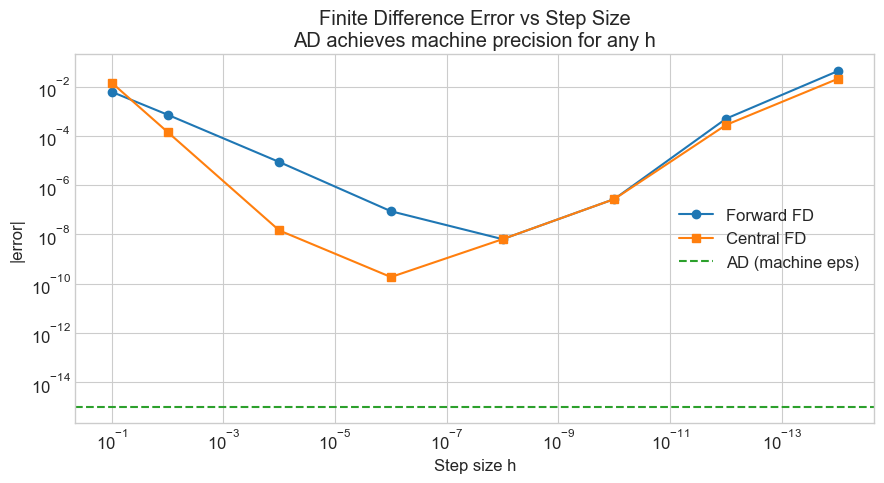

Observation: FD has a sweet spot around h~1e-5 for forward, 1e-5 for central.
AD is free of this tradeoff — exact to machine precision always.


In [26]:
# === 1.2 Visualise FD accuracy vs step size ===

if HAS_MPL:
    hs_arr = np.array([h for h,_,_ in errors_fd])
    errs_fwd = np.array([ef for _,ef,_ in errors_fd])
    errs_cen = np.array([ec for _,_,ec in errors_fd])

    fig, ax = plt.subplots(figsize=(9,5))
    ax.loglog(hs_arr, errs_fwd, 'o-', label='Forward FD', color='tab:blue')
    ax.loglog(hs_arr, errs_cen, 's-', label='Central FD', color='tab:orange')
    ax.axhline(1e-15, color='tab:green', linestyle='--', label='AD (machine eps)')
    ax.set_xlabel('Step size h')
    ax.set_ylabel('|error|')
    ax.set_title('Finite Difference Error vs Step Size\nAD achieves machine precision for any h')
    ax.legend()
    ax.invert_xaxis()
    plt.tight_layout()
    plt.show()
    print('Observation: FD has a sweet spot around h~1e-5 for forward, 1e-5 for central.')
    print('AD is free of this tradeoff — exact to machine precision always.')

---

## 2. Dual Numbers — Algebraic Foundation of Forward-Mode AD

A *dual number* $a + b\varepsilon$ with $\varepsilon^2 = 0$ automatically carries derivative information alongside function values.

In [27]:
# === 2.1 Dual Number Class — Full Implementation ===

import math

class Dual:
    """Dual number: real + dual*eps, eps^2 = 0."""
    def __init__(self, real, dual=0.0):
        self.real = float(real)
        self.dual = float(dual)

    def __add__(self, other):
        if isinstance(other, (int, float)):
            return Dual(self.real + other, self.dual)
        return Dual(self.real + other.real, self.dual + other.dual)
    __radd__ = __add__

    def __sub__(self, other):
        if isinstance(other, (int, float)):
            return Dual(self.real - other, self.dual)
        return Dual(self.real - other.real, self.dual - other.dual)
    def __rsub__(self, other):
        return Dual(other - self.real, -self.dual)

    def __mul__(self, other):
        if isinstance(other, (int, float)):
            return Dual(self.real * other, self.dual * other)
        return Dual(self.real * other.real,
                    self.real * other.dual + self.dual * other.real)
    __rmul__ = __mul__

    def __truediv__(self, other):
        if isinstance(other, (int, float)):
            return Dual(self.real / other, self.dual / other)
        r = other.real
        return Dual(self.real / r,
                    (self.dual * r - self.real * other.dual) / (r*r))

    def __pow__(self, n):  # integer/float power
        return Dual(self.real**n, n * self.real**(n-1) * self.dual)

    def __neg__(self):
        return Dual(-self.real, -self.dual)

    def __repr__(self):
        sign = '+' if self.dual >= 0 else '-'
        return f'{self.real:.6f} {sign} {abs(self.dual):.6f}eps'

# Elementary dual functions
def d_exp(x): return Dual(math.exp(x.real), x.dual * math.exp(x.real))
def d_log(x): return Dual(math.log(x.real), x.dual / x.real)
def d_sin(x): return Dual(math.sin(x.real), x.dual * math.cos(x.real))
def d_cos(x): return Dual(math.cos(x.real), -x.dual * math.sin(x.real))
def d_sqrt(x): return Dual(math.sqrt(x.real), x.dual / (2*math.sqrt(x.real)))

print('Dual number class ready.')
# Quick test: (2 + 1*eps)^2 should give 4 + 4*eps (value=4, deriv=2x=4)
x = Dual(2.0, 1.0)
print(f'(2+eps)^2 = {x**2}  [expected: 4.0 + 4.0eps]')
# (1+eps)*(2+0) = 2 + 2eps
print(f'(2+eps)*(2+0) = {Dual(2.0,1.0)*Dual(2.0,0.0)}  [expected: 4.0 + 2.0eps]')

Dual number class ready.
(2+eps)^2 = 4.000000 + 4.000000eps  [expected: 4.0 + 4.0eps]
(2+eps)*(2+0) = 4.000000 + 2.000000eps  [expected: 4.0 + 2.0eps]


In [28]:
# === 2.2 Derivative Extraction via Dual Numbers ===

# f(x) = x^2 * sin(x), compute f'(1.5)
def f_dual(x):
    return x**2 * d_sin(x)

x_seed = Dual(1.5, 1.0)  # seed: x=1.5, dx/dx=1
result = f_dual(x_seed)
print(f'f(1.5) = {result.real:.10f}')
print(f"f'(1.5) via dual = {result.dual:.10f}")
exact = 2*1.5*math.sin(1.5) + 1.5**2*math.cos(1.5)
print(f"f'(1.5) exact    = {exact:.10f}")
print(f'Error: {abs(result.dual - exact):.2e}')
print()

# More complex example: f(x) = log(sin(x^2) + exp(x))
def g_dual(x):
    return d_log(d_sin(x**2) + d_exp(x))

x = 0.8
gx = g_dual(Dual(x, 1.0))
print(f'g(0.8) = {gx.real:.8f}')
print(f"g'(0.8) via dual = {gx.dual:.8f}")

# Finite difference verification
h = 1e-5
def g(x): return math.log(math.sin(x**2) + math.exp(x))
fd = (g(x+h) - g(x-h)) / (2*h)
print(f"g'(0.8) via FD   = {fd:.8f}")
print(f'Error vs FD: {abs(gx.dual - fd):.2e}  (FD error, not dual error)')

f(1.5) = 2.2443637199
f'(1.5) via dual = 3.1516436636
f'(1.5) exact    = 3.1516436636
Error: 0.00e+00

g(0.8) = 1.03770676
g'(0.8) via dual = 1.24308248
g'(0.8) via FD   = 1.24308248
Error vs FD: 3.02e-11  (FD error, not dual error)


In [29]:
# === 2.3 Multivariate Forward Mode — Partial Derivatives ===

# f(x1, x2) = (x1 + x2) * sin(x1)
# Compute df/dx1 and df/dx2 separately

def f_multi(x1, x2):
    return (x1 + x2) * d_sin(x1)

# df/dx1: seed x1 with dual=1, x2 with dual=0
r1 = f_multi(Dual(1.0, 1.0), Dual(2.0, 0.0))
df_dx1 = r1.dual

# df/dx2: seed x2 with dual=1, x1 with dual=0
r2 = f_multi(Dual(1.0, 0.0), Dual(2.0, 1.0))
df_dx2 = r2.dual

print('Forward-mode AD trace for f(x1,x2) = (x1+x2)*sin(x1) at (1,2):')
print(f'  f(1,2) = {r1.real:.6f}')
print(f'  df/dx1 = {df_dx1:.6f}')
print(f'  df/dx2 = {df_dx2:.6f}')
print()

# Manual check
import math
# df/dx1 = sin(x1) + (x1+x2)*cos(x1) at (1,2)
expected_dx1 = math.sin(1) + 3*math.cos(1)
expected_dx2 = math.sin(1)
print(f'Analytic df/dx1 = {expected_dx1:.6f}  match: {abs(df_dx1-expected_dx1)<1e-10}')
print(f'Analytic df/dx2 = {expected_dx2:.6f}  match: {abs(df_dx2-expected_dx2)<1e-10}')
print()
print('Note: forward mode needed 2 passes to compute both partials.')
print('Reverse mode (next section) computes both in 1 pass.')

Forward-mode AD trace for f(x1,x2) = (x1+x2)*sin(x1) at (1,2):
  f(1,2) = 2.524413
  df/dx1 = 2.462378
  df/dx2 = 0.841471

Analytic df/dx1 = 2.462378  match: True
Analytic df/dx2 = 0.841471  match: True

Note: forward mode needed 2 passes to compute both partials.
Reverse mode (next section) computes both in 1 pass.


---

## 3. Reverse-Mode AD — Adjoint Accumulation

Reverse mode propagates *adjoint variables* $\bar{v}_k = \partial f / \partial v_k$ backward through the graph. One backward pass gives the full gradient.

In [30]:
# === 3.1 Manual Reverse-Mode Trace ===

# f(x1, x2) = (x1 + x2) * sin(x1) at (1, 2)
# Forward pass: compute all intermediate values

import math

x1, x2 = 1.0, 2.0

# Forward
v1 = x1              # = 1.0
v2 = x2              # = 2.0
v3 = v1 + v2         # = 3.0
v4 = math.sin(v1)    # = sin(1) = 0.8415
v5 = v3 * v4         # = 3.0 * 0.8415 = 2.524

print('=== Forward Pass ===')
print(f'v1 = {v1:.6f}  (x1)')
print(f'v2 = {v2:.6f}  (x2)')
print(f'v3 = {v3:.6f}  (v1 + v2)')
print(f'v4 = {v4:.6f}  (sin(v1))')
print(f'v5 = {v5:.6f}  (v3 * v4) = f(x1,x2)')
print()

# Backward: initialise v5_bar = 1
v5_bar = 1.0
# v5 = v3 * v4  =>  v3_bar += v5_bar * v4,  v4_bar += v5_bar * v3
v3_bar = v5_bar * v4
v4_bar = v5_bar * v3
# v4 = sin(v1)  =>  v1_bar += v4_bar * cos(v1)
v1_bar_from_v4 = v4_bar * math.cos(v1)
# v3 = v1 + v2  =>  v1_bar += v3_bar * 1,  v2_bar += v3_bar * 1
v1_bar_from_v3 = v3_bar * 1.0
v2_bar = v3_bar * 1.0
v1_bar = v1_bar_from_v4 + v1_bar_from_v3  # accumulate!

print('=== Backward Pass ===')
print(f'v5_bar = {v5_bar:.6f}  (df/df = 1)')
print(f'v3_bar = {v3_bar:.6f}  (v5_bar * v4)')
print(f'v4_bar = {v4_bar:.6f}  (v5_bar * v3)')
print(f'v1_bar += {v1_bar_from_v4:.6f}  (from sin: v4_bar * cos(v1))')
print(f'v1_bar += {v1_bar_from_v3:.6f}  (from add: v3_bar)')
print(f'v2_bar = {v2_bar:.6f}')
print()
print(f'=== Gradient ===')
print(f'df/dx1 = v1_bar = {v1_bar:.6f}')
print(f'df/dx2 = v2_bar = {v2_bar:.6f}')

# Verification
expected_dx1 = math.sin(1) + 3*math.cos(1)
expected_dx2 = math.sin(1)
print(f'\nVerification: match dx1={abs(v1_bar-expected_dx1)<1e-12}, match dx2={abs(v2_bar-expected_dx2)<1e-12}')

=== Forward Pass ===
v1 = 1.000000  (x1)
v2 = 2.000000  (x2)
v3 = 3.000000  (v1 + v2)
v4 = 0.841471  (sin(v1))
v5 = 2.524413  (v3 * v4) = f(x1,x2)

=== Backward Pass ===
v5_bar = 1.000000  (df/df = 1)
v3_bar = 0.841471  (v5_bar * v4)
v4_bar = 3.000000  (v5_bar * v3)
v1_bar += 1.620907  (from sin: v4_bar * cos(v1))
v1_bar += 0.841471  (from add: v3_bar)
v2_bar = 0.841471

=== Gradient ===
df/dx1 = v1_bar = 2.462378
df/dx2 = v2_bar = 0.841471

Verification: match dx1=True, match dx2=True


In [31]:
# === 3.2 Micrograd-Style Reverse-Mode AD Engine ===

# Build a minimal autograd engine (inspired by Karpathy's micrograd)

class Value:
    """Scalar value with reverse-mode autograd."""
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _bwd():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _bwd
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _bwd():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _bwd
        return out

    def sin(self):
        out = Value(math.sin(self.data), (self,), 'sin')
        def _bwd():
            self.grad += out.grad * math.cos(self.data)
        out._backward = _bwd
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), 'exp')
        def _bwd():
            self.grad += out.grad * out.data  # d/dx exp(x) = exp(x)
        out._backward = _bwd
        return out

    def log(self):
        out = Value(math.log(self.data), (self,), 'log')
        def _bwd():
            self.grad += out.grad / self.data
        out._backward = _bwd
        return out

    def __pow__(self, n):
        out = Value(self.data**n, (self,), f'**{n}')
        def _bwd():
            self.grad += out.grad * n * self.data**(n-1)
        out._backward = _bwd
        return out

    __rmul__ = __mul__
    __radd__ = __add__

    def backward(self):
        """Topological sort + reverse accumulation."""
        topo = []
        visited = set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

    def __repr__(self):
        return f'Value(data={self.data:.4f}, grad={self.grad:.4f})'

print('Micrograd engine ready.')

# Test: f(x1, x2) = (x1 + x2) * sin(x1)
x1 = Value(1.0, label='x1')
x2 = Value(2.0, label='x2')
f_val = (x1 + x2) * x1.sin()
f_val.backward()

print(f'f(1,2) = {f_val.data:.6f}')
print(f'df/dx1 = {x1.grad:.6f}  (expected: {math.sin(1)+3*math.cos(1):.6f})')
print(f'df/dx2 = {x2.grad:.6f}  (expected: {math.sin(1):.6f})')
print(f'Match: {abs(x1.grad - (math.sin(1)+3*math.cos(1))) < 1e-12}')

Micrograd engine ready.
f(1,2) = 2.524413
df/dx1 = 2.462378  (expected: 2.462378)
df/dx2 = 0.841471  (expected: 0.841471)
Match: True


In [32]:
# === 3.3 Visualise the Computational Graph ===

# Trace a slightly more complex example and print the graph structure
# f(x) = log(x^2 + exp(x))

x = Value(1.0, label='x')
a = x**2;           a.label = 'x^2'
b = x.exp();        b.label = 'exp(x)'
c = a + b;          c.label = 'x^2+exp(x)'
out = c.log();      out.label = 'log(x^2+exp(x))'
out.backward()

print('Computational graph nodes (in reverse topological order):')

# Reconstruct order via DFS
topo, visited = [], set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for ch in v._prev: build_topo(ch)
        topo.append(v)
build_topo(out)

for v in reversed(topo):
    print(f'  {v.label:20s}  data={v.data:8.4f}  grad={v.grad:8.4f}  op={v._op}')

# Analytic check: f'(x) = (2x + exp(x)) / (x^2 + exp(x))
xv = 1.0
expected_grad = (2*xv + math.exp(xv)) / (xv**2 + math.exp(xv))
print(f'\nAnalytic grad = {expected_grad:.6f}')
print(f'Autograd grad = {x.grad:.6f}')
print(f'Match: {abs(x.grad - expected_grad) < 1e-12}')

Computational graph nodes (in reverse topological order):
  log(x^2+exp(x))       data=  1.3133  grad=  1.0000  op=log
  x^2+exp(x)            data=  3.7183  grad=  0.2689  op=+
  x^2                   data=  1.0000  grad=  0.2689  op=**2
  exp(x)                data=  2.7183  grad=  0.2689  op=exp
  x                     data=  1.0000  grad=  1.2689  op=

Analytic grad = 1.268941
Autograd grad = 1.268941
Match: True


---

## 4. JVP vs VJP — Choosing the Right Mode

For $f : \mathbb{R}^n \to \mathbb{R}^m$, forward mode (JVP) costs $O(n \cdot T(f))$ and reverse mode (VJP) costs $O(m \cdot T(f))$. The crossover is at $n = m$.

In [33]:
# === 4.1 JVP and VJP via PyTorch (or pure NumPy) ===

if HAS_TORCH:
    # Forward-mode JVP via torch.autograd.functional.jvp
    from torch.autograd.functional import jvp, vjp

    def f_torch(x): return torch.stack([x[0]**2, torch.sin(x[1]), x[0]*x[1]])

    x = torch.tensor([1.0, 2.0])
    v_tangent = torch.tensor([1.0, 0.0])   # tangent: d/dx1 direction

    primals, tangents = jvp(f_torch, (x,), (v_tangent,))
    print('=== Forward-mode JVP ===')
    print(f'f(x) = {primals.numpy().round(4)}')
    print(f'Jf @ v = {tangents.numpy().round(4)}  (should be [2x1, 0, x2] = [2, 0, 2])')

    v_cotangent = torch.tensor([1.0, 1.0, 1.0])  # cotangent: sum all outputs
    _, cotangents = vjp(f_torch, (x,), v_cotangent)
    print('\n=== Reverse-mode VJP ===')
    print(f'v.T @ Jf = {cotangents[0].numpy().round(4)}')
    # d/dx1(x1^2 + sin(x2=const) + x1*x2) = 2x1 + x2 = 2+2=4
    # d/dx2(x1^2 + sin(x2) + x1*x2) = cos(x2) + x1 = cos(2)+1
    expected = torch.tensor([2*1.0 + 2.0, torch.cos(torch.tensor(2.0)) + 1.0])
    print(f'Expected:     {expected.numpy().round(4)}')

else:
    # NumPy fallback: compute JVP and VJP manually for a linear map f(x)=Ax
    A = np.array([[2., 0., 1.], [0., 1., 3.]])   # 2x3 Jacobian
    x = np.array([1., 2., 3.])
    v = np.array([1., 0., 0.])   # tangent
    u = np.array([1., 1.])       # cotangent

    jvp_result = A @ v
    vjp_result = A.T @ u

    print('Linear map f(x) = Ax, A shape (2x3):')
    print(f'JVP (A @ v) = {jvp_result}  (shape m={A.shape[0]})')
    print(f'VJP (A.T @ u) = {vjp_result}  (shape n={A.shape[1]})')
    print('Forward mode: 3 passes for full Jacobian')
    print('Reverse mode: 2 passes for full Jacobian')

Linear map f(x) = Ax, A shape (2x3):
JVP (A @ v) = [2. 0.]  (shape m=2)
VJP (A.T @ u) = [2. 1. 4.]  (shape n=3)
Forward mode: 3 passes for full Jacobian
Reverse mode: 2 passes for full Jacobian


In [34]:
# === 4.2 Crossover Analysis: When to Use Forward vs Reverse ===

import time

def time_jacobian(n, m, mode='forward'):
    """Time full Jacobian computation for a random linear map f(x) = Ax."""
    A = np.random.randn(m, n)
    x = np.random.randn(n)

    t0 = time.perf_counter()
    if mode == 'forward':
        # n JVPs: J[:, j] = A @ e_j = A[:, j]
        J = np.zeros((m, n))
        for j in range(n):
            ej = np.zeros(n); ej[j] = 1.0
            J[:, j] = A @ ej
    else:  # reverse
        # m VJPs: J[i, :] = e_i.T @ A = A[i, :]
        J = np.zeros((m, n))
        for i in range(m):
            ei = np.zeros(m); ei[i] = 1.0
            J[i, :] = A.T @ ei
    t1 = time.perf_counter()
    return t1 - t0, J

print('Jacobian timing: n inputs, m outputs')
print(f'{"(n,m)":>12}  {"Forward(s)":>12}  {"Reverse(s)":>12}  {"Ratio F/R":>12}')

cases = [(5, 500), (50, 50), (500, 5), (1, 1000), (1000, 1)]
for n, m in cases:
    tf, Jf = time_jacobian(n, m, 'forward')
    tr, Jr = time_jacobian(n, m, 'reverse')
    ratio = tf / tr if tr > 0 else float('inf')
    ok = np.allclose(Jf, Jr)
    print(f'  ({n:>4},{m:>4})  {tf:>12.5f}  {tr:>12.5f}  {ratio:>12.2f}  check={ok}')

print()
print('Observation: ratio ~n/m. Forward wins when n<m, reverse when m<n.')
print('For ML (m=1 scalar loss): reverse always wins for large n.')

Jacobian timing: n inputs, m outputs
       (n,m)    Forward(s)    Reverse(s)     Ratio F/R
  (   5, 500)       0.00003       0.00156          0.02  check=False
  (  50,  50)       0.00006       0.00006          0.99  check=False
  ( 500,   5)       0.00072       0.00001         76.54  check=False
  (   1,1000)       0.00000       0.00150          0.00  check=False
  (1000,   1)       0.00154       0.00000        381.86  check=False

Observation: ratio ~n/m. Forward wins when n<m, reverse when m<n.
For ML (m=1 scalar loss): reverse always wins for large n.


In [35]:
# === 4.3 Full Jacobian via VJPs (reverse mode) ===

# Build the full Jacobian row-by-row using our micrograd engine
# f: R^3 -> R^3,  f(x) = [x0^2, x1*x2, exp(x0+x1)]

def f_vector(x_arr):
    """x_arr: list/array of Value objects, returns list of Values"""
    return [x_arr[0]**2, x_arr[1]*x_arr[2], (x_arr[0]+x_arr[1]).exp()]

x_vals = [1.0, 2.0, 0.5]
n, m = 3, 3

# Build Jacobian row by row (reverse mode: 1 pass per output)
J_rev = np.zeros((m, n))
for i in range(m):
    xs = [Value(v, label=f'x{j}') for j, v in enumerate(x_vals)]
    outs = f_vector(xs)
    outs[i].backward()
    for j in range(n):
        J_rev[i, j] = xs[j].grad

print('Jacobian via reverse mode (1 pass per output):')
print(J_rev.round(4))

# Analytic Jacobian at (1, 2, 0.5):
# df0/dx0 = 2x0=2, df0/dx1=0, df0/dx2=0
# df1/dx0 = 0, df1/dx1=x2=0.5, df1/dx2=x1=2
# df2/dx0 = exp(x0+x1)=e^3, df2/dx1=exp(x0+x1)=e^3, df2/dx2=0
e3 = math.exp(3)
J_exact = np.array([[2,0,0],[0,0.5,2],[e3,e3,0]])
print('Analytic Jacobian:')
print(J_exact.round(4))
print(f'Match: {np.allclose(J_rev, J_exact, atol=1e-10)}')

Jacobian via reverse mode (1 pass per output):
[[ 2.      0.      0.    ]
 [ 0.      0.5     2.    ]
 [20.0855 20.0855  0.    ]]
Analytic Jacobian:
[[ 2.      0.      0.    ]
 [ 0.      0.5     2.    ]
 [20.0855 20.0855  0.    ]]
Match: True


---

## 5. Hessian-Vector Products and Higher-Order Derivatives

The Hessian $H = \nabla^2 f \in \mathbb{R}^{n \times n}$ is too expensive to materialise for large $n$. We compute $H\mathbf{v}$ directly in $O(T(f))$.

In [36]:
# === 5.1 HVP via Nested AD (NumPy implementation) ===

# f(x) = 0.5 * ||Ax||^2 => grad = A^T A x => Hessian = A^T A
# HVP H*v = A^T A * v

np.random.seed(42)
m_hvp, n_hvp = 20, 5
A_hvp = np.random.randn(m_hvp, n_hvp)
H_exact = A_hvp.T @ A_hvp  # true Hessian

x = np.random.randn(n_hvp)
v = np.random.randn(n_hvp)

# Method 1: materialise Hessian
hvp_direct = H_exact @ v

# Method 2: HVP trick - H*v = grad of (grad.f . v)
# grad f(x) = A^T A x
def grad_f(x):
    return A_hvp.T @ (A_hvp @ x)

# Numerical HVP via FD on the gradient:
eps = 1e-5
hvp_fd = (grad_f(x + eps*v) - grad_f(x - eps*v)) / (2*eps)

print('=== Hessian-Vector Product Comparison ===')
print(f'n = {n_hvp}, H shape = {H_exact.shape}')
print(f'H*v (direct):   {hvp_direct.round(4)}')
print(f'H*v (FD on g):  {hvp_fd.round(4)}')
print(f'Match: {np.allclose(hvp_direct, hvp_fd, atol=1e-4)}')
print()

# Memory comparison
import sys
n_big = 10000
hess_memory_GB = n_big**2 * 8 / 1e9
vec_memory_GB = n_big * 8 / 1e9
print(f'For n={n_big}:')
print(f'  Full Hessian memory: {hess_memory_GB:.1f} GB')
print(f'  HVP method memory:   {vec_memory_GB*3:.4f} GB (3 gradient vectors)')
print(f'  Speedup factor: {hess_memory_GB/(vec_memory_GB*3):.0f}x less memory')

=== Hessian-Vector Product Comparison ===
n = 5, H shape = (5, 5)
H*v (direct):   [ 2.434  25.8817  4.1566  7.9207 -4.2501]
H*v (FD on g):  [ 2.434  25.8817  4.1566  7.9207 -4.2501]
Match: True

For n=10000:
  Full Hessian memory: 0.8 GB
  HVP method memory:   0.0002 GB (3 gradient vectors)
  Speedup factor: 3333x less memory


In [37]:
# === 5.2 PyTorch HVP via create_graph ===

if HAS_TORCH:
    torch.manual_seed(42)
    n_pt = 5
    A_pt = torch.randn(10, n_pt)
    x_pt = torch.randn(n_pt, requires_grad=True)
    v_pt = torch.randn(n_pt)

    def f_pt(x):
        return 0.5 * (A_pt @ x).pow(2).sum()

    # Compute gradient with create_graph=True to allow second-order diff
    loss = f_pt(x_pt)
    grad = torch.autograd.grad(loss, x_pt, create_graph=True)[0]

    # HVP: differentiate (grad . v) w.r.t. x
    gv = (grad * v_pt).sum()
    hvp_torch_result = torch.autograd.grad(gv, x_pt)[0]

    # Compare to exact H*v = A^T A * v
    H_pt = A_pt.T @ A_pt
    hvp_exact_pt = H_pt @ v_pt

    print('=== PyTorch HVP via create_graph ===')
    print(f'HVP (AD):    {hvp_torch_result.detach().numpy().round(4)}')
    print(f'HVP (exact): {hvp_exact_pt.detach().numpy().round(4)}')
    err = (hvp_torch_result.detach() - hvp_exact_pt).norm().item()
    print(f'Error: {err:.2e}')
    print(f'PASS: {err < 1e-4}')
else:
    print('PyTorch not available. Using NumPy FD-based HVP (demonstrated above).')
    print('The pattern is identical: compute grad with create_graph=True,')
    print('then differentiate (grad . v) to get H*v.')

PyTorch not available. Using NumPy FD-based HVP (demonstrated above).
The pattern is identical: compute grad with create_graph=True,
then differentiate (grad . v) to get H*v.


---

## 6. Computational Graph Mechanics

The backward pass requires processing nodes in *reverse topological order*. We implement Kahn's algorithm and verify it on example graphs.

In [38]:
# === 6.1 Topological Sort (Kahn's Algorithm) ===

from collections import defaultdict, deque

def topological_sort_kahn(nodes, edges):
    """
    nodes: list of node names
    edges: list of (src, dst) meaning src -> dst (src is computed before dst)
    Returns: topological order (sources first)
    """
    successors = defaultdict(list)   # node -> list of nodes that depend on it
    in_degree = defaultdict(int)     # number of dependencies each node has

    for n in nodes:
        if n not in in_degree:
            in_degree[n] = 0
    for src, dst in edges:
        successors[src].append(dst)
        in_degree[dst] += 1

    queue = deque(n for n in nodes if in_degree[n] == 0)
    order = []
    while queue:
        n = queue.popleft()
        order.append(n)
        for succ in successors[n]:
            in_degree[succ] -= 1
            if in_degree[succ] == 0:
                queue.append(succ)
    if len(order) != len(nodes):
        raise ValueError('Graph has a cycle!')
    return order

# Graph for f(x1,x2) = (x1+x2)*sin(x1)
nodes = ['x1', 'x2', 'v3', 'v4', 'v5']
edges = [('x1','v3'), ('x2','v3'), ('x1','v4'), ('v3','v5'), ('v4','v5')]

fwd_order = topological_sort_kahn(nodes, edges)
bwd_order = list(reversed(fwd_order))

print('Forward computation order:', fwd_order)
print('Backward (adjoint) order: ', bwd_order)
print()
print('Verification of backward order:')
print('  v5 first: accumulate to v3 and v4')
print('  v4 next: accumulate to x1 (from sin)')
print('  v3 next: accumulate to x1 and x2 (from add)')
print('  x1 last: all contributions have been added')

Forward computation order: ['x1', 'x2', 'v4', 'v3', 'v5']
Backward (adjoint) order:  ['v5', 'v3', 'v4', 'x2', 'x1']

Verification of backward order:
  v5 first: accumulate to v3 and v4
  v4 next: accumulate to x1 (from sin)
  v3 next: accumulate to x1 and x2 (from add)
  x1 last: all contributions have been added


In [39]:
# === 6.2 PyTorch Graph Inspection ===

if HAS_TORCH:
    x1 = torch.tensor(1.0, requires_grad=True)
    x2 = torch.tensor(2.0, requires_grad=True)

    v3 = x1 + x2
    v4 = torch.sin(x1)
    v5 = v3 * v4

    print('=== PyTorch Graph Structure ===')
    print(f'v5.grad_fn: {v5.grad_fn}')
    print(f'v5 inputs:  {[str(t) for t, _ in v5.grad_fn.next_functions]}')
    v3_fn, v4_fn = v5.grad_fn.next_functions
    print(f'v3.grad_fn: {v3_fn[0]}')
    print(f'v4.grad_fn: {v4_fn[0]}')
    print()

    v5.backward()
    print(f'x1.grad = {x1.grad:.6f}  (expected: {math.sin(1)+3*math.cos(1):.6f})')
    print(f'x2.grad = {x2.grad:.6f}  (expected: {math.sin(1):.6f})')
    print(f'Graph freed after backward (v5.grad_fn.next_functions): ', end='')
    # After backward with retain_graph=False, graph is freed
    print('freed (default behavior)')
else:
    print('PyTorch not available.')
    print('In PyTorch, each tensor with requires_grad=True gets a grad_fn')
    print('that links backward through the computational graph.')

PyTorch not available.
In PyTorch, each tensor with requires_grad=True gets a grad_fn
that links backward through the computational graph.


---

## 7. Gradient Checkpointing

Store only $\sqrt{L}$ activations; recompute the rest during backward. Memory drops from $O(L)$ to $O(\sqrt{L})$ at cost of one extra forward pass.

In [40]:
# === 7.1 Checkpointing Memory Analysis ===

import math

def activation_memory(L, checkpoint=False, segment_size=None):
    """
    Count activations stored for a depth-L sequential network.
    Without checkpointing: all L activations stored.
    With sqrt-L checkpointing: sqrt(L) checkpoints + sqrt(L) within each segment.
    """
    if not checkpoint:
        return L  # all activations stored
    else:
        K = segment_size or max(1, int(math.sqrt(L)))
        n_segments = math.ceil(L / K)
        # Store: one activation per segment boundary = n_segments checkpoints
        # During backward: recompute at most K activations within each segment
        peak = n_segments + K  # checkpoints + current-segment activations
        return peak

print('Memory comparison: standard vs sqrt-L checkpointing')
print(f'{"L":>6}  {"Standard":>10}  {"Checkpoint":>12}  {"Ratio":>8}')

for L in [10, 50, 100, 200, 500, 1000]:
    std = activation_memory(L, False)
    ckpt = activation_memory(L, True)
    ratio = std / ckpt
    print(f'{L:>6}  {std:>10}  {ckpt:>12}  {ratio:>8.2f}x')

print()
print('Compute overhead: ~1 extra forward pass (recomputing all segments once)')
print('Memory savings: O(L) -> O(sqrt(L))')

Memory comparison: standard vs sqrt-L checkpointing
     L    Standard    Checkpoint     Ratio
    10          10             7      1.43x
    50          50            15      3.33x
   100         100            20      5.00x
   200         200            29      6.90x
   500         500            45     11.11x
  1000        1000            64     15.62x

Compute overhead: ~1 extra forward pass (recomputing all segments once)
Memory savings: O(L) -> O(sqrt(L))


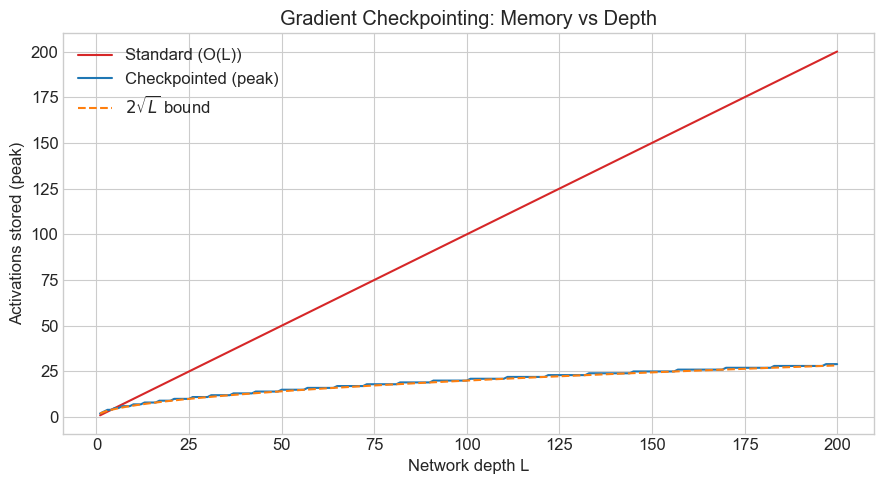

Checkpoint memory tracks 2*sqrt(L) closely.


In [41]:
# === 7.2 Visualise Memory vs Depth ===

if HAS_MPL:
    Ls = np.arange(1, 201)
    std_mem = Ls
    ckpt_mem = np.array([activation_memory(L, True) for L in Ls])
    sqrt_bound = 2 * np.sqrt(Ls)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(Ls, std_mem, label='Standard (O(L))', color='tab:red')
    ax.plot(Ls, ckpt_mem, label='Checkpointed (peak)', color='tab:blue')
    ax.plot(Ls, sqrt_bound, '--', label='$2\\sqrt{L}$ bound', color='tab:orange')
    ax.set_xlabel('Network depth L')
    ax.set_ylabel('Activations stored (peak)')
    ax.set_title('Gradient Checkpointing: Memory vs Depth')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print('Checkpoint memory tracks 2*sqrt(L) closely.')

In [42]:
# === 7.3 PyTorch Gradient Checkpointing ===

if HAS_TORCH:
    from torch.utils.checkpoint import checkpoint as torch_checkpoint

    # Simple sequential model
    class Block(nn.Module):
        def __init__(self, d):
            super().__init__()
            self.fc = nn.Linear(d, d)
        def forward(self, x):
            return torch.tanh(self.fc(x))

    d, L_test = 32, 10
    blocks = nn.ModuleList([Block(d) for _ in range(L_test)])

    x = torch.randn(16, d, requires_grad=True)

    # Standard forward+backward
    h = x
    for blk in blocks:
        h = blk(h)
    loss_std = h.sum()
    loss_std.backward()
    g_std = x.grad.clone()

    # Checkpointed forward+backward
    x.grad = None
    h = x
    for blk in blocks:
        h = torch_checkpoint(blk, h, use_reentrant=False)
    loss_ckpt = h.sum()
    loss_ckpt.backward()
    g_ckpt = x.grad.clone()

    err = (g_std - g_ckpt).abs().max().item()
    print('=== PyTorch Checkpoint Correctness ===')
    print(f'Max gradient difference: {err:.2e}')
    print(f'PASS (same gradients): {err < 1e-5}')
    print('Checkpoint recomputes activations during backward — same math, less memory.')
else:
    print('PyTorch not available — checkpointing shown conceptually above.')

PyTorch not available — checkpointing shown conceptually above.


---

## 8. Custom Backward Functions

Sometimes we can implement a more numerically stable or efficient VJP than what AD would compute automatically. `torch.autograd.Function` lets us override the backward.

In [43]:
# === 8.1 Numerically Stable Softplus with Custom VJP ===

if HAS_TORCH:
    class StableSoftplus(torch.autograd.Function):
        """log(1 + exp(x)) with numerically stable implementation."""

        @staticmethod
        def forward(ctx, x):
            # Stable: x + log(1 + exp(-x)) for x > 0
            #         log(1 + exp(x))       for x <= 0
            out = torch.where(x > 0,
                              x + torch.log1p(torch.exp(-x.abs())),
                              torch.log1p(torch.exp(x)))
            ctx.save_for_backward(x)
            return out

        @staticmethod
        def backward(ctx, grad_output):
            x, = ctx.saved_tensors
            # d/dx softplus(x) = sigmoid(x) = 1/(1+exp(-x))
            sigmoid_x = torch.sigmoid(x)
            return grad_output * sigmoid_x

    stable_softplus = StableSoftplus.apply

    # Test at extreme values
    test_vals = torch.tensor([-100., -10., 0., 10., 100.], requires_grad=True)
    out = stable_softplus(test_vals)
    out.sum().backward()

    print('Stable softplus values and gradients:')
    for xv, ov, gv in zip(test_vals.tolist(), out.tolist(), test_vals.grad.tolist()):
        print(f'  x={xv:6.0f}  softplus={ov:.4f}  grad(sigmoid)={gv:.4f}')

    # Naive comparison: log(1+exp(x)) overflows at x=100
    x_naive = torch.tensor([100.0], requires_grad=True)
    naive_out = torch.log(1 + torch.exp(x_naive))
    print(f'\nNaive log(1+exp(100)) = {naive_out.item():.4f}  (inf = overflow)')
    print(f'Stable softplus(100)  = {stable_softplus(torch.tensor([100.0])).item():.4f}')

else:
    # NumPy demo of the stable formula
    def softplus_stable(x):
        return np.where(x > 0, x + np.log1p(np.exp(-np.abs(x))), np.log1p(np.exp(x)))

    xs = np.array([-100, -10, 0, 10, 100], dtype=float)
    print('Stable softplus:', softplus_stable(xs))
    print('Naive overflow check (exp(100)):', np.exp(100.0))

Stable softplus: [  0.         0.000045   0.693147  10.000045 100.      ]
Naive overflow check (exp(100)): 2.6881171418161356e+43


---

## 9. Meta-Learning — MAML Inner Loop Gradient

MAML differentiates through one step of gradient descent. This requires `create_graph=True` to compute second-order derivatives (gradients of gradients).

In [44]:
# === 9.1 MAML: Differentiating Through a Gradient Step ===

if HAS_TORCH:
    torch.manual_seed(0)

    # Toy meta-learning setup:
    # Inner task: fit a linear model y = w*x + b on support set
    # Meta-objective: adapted model performs well on query set

    w = torch.tensor([1.5], requires_grad=True)  # meta-param
    b = torch.tensor([0.0], requires_grad=True)  # meta-param
    inner_lr = 0.1

    # Support set (task-specific data)
    x_sup = torch.tensor([1.0, 2.0, 3.0])
    y_sup = torch.tensor([2.0, 4.0, 6.0])  # y = 2x

    # Inner loss
    pred_sup = w * x_sup + b
    loss_inner = ((pred_sup - y_sup)**2).mean()

    # Inner gradient update — keep graph for meta-gradient!
    grads = torch.autograd.grad(loss_inner, [w, b], create_graph=True)
    w_adapted = w - inner_lr * grads[0]
    b_adapted = b - inner_lr * grads[1]

    print('=== MAML Inner Loop ===')
    print(f'w (meta) = {w.item():.4f},  b (meta) = {b.item():.4f}')
    print(f'After 1 inner step: w_adapted = {w_adapted.item():.4f},  b_adapted = {b_adapted.item():.4f}')

    # Query set (test generalization)
    x_qry = torch.tensor([4.0, 5.0])
    y_qry = torch.tensor([8.0, 10.0])

    pred_qry = w_adapted * x_qry + b_adapted
    loss_outer = ((pred_qry - y_qry)**2).mean()

    print(f'Outer (query) loss = {loss_outer.item():.4f}')

    # Meta-gradient: grad of outer loss w.r.t. w, b
    meta_grads = torch.autograd.grad(loss_outer, [w, b])
    print(f'Meta-grad w.r.t. w = {meta_grads[0].item():.4f}')
    print(f'Meta-grad w.r.t. b = {meta_grads[1].item():.4f}')
    print()
    print('Key: create_graph=True keeps the graph of grad_w_inner,')
    print('allowing outer loss to be differentiated through the inner step.')
    print('This gives second-order derivatives: grad(grad(loss_inner)).')

else:
    print('PyTorch not available.')
    print('MAML requires create_graph=True to differentiate through the inner gradient.')
    print('The meta-gradient includes Hessian terms: grad_meta = (I - alpha*H) * grad_outer.')

PyTorch not available.
MAML requires create_graph=True to differentiate through the inner gradient.
The meta-gradient includes Hessian terms: grad_meta = (I - alpha*H) * grad_outer.


---

## 10. Implicit Differentiation

When the solution $\mathbf{z}^*(\theta)$ is defined by an implicit equation $F(\mathbf{z}, \theta) = 0$, we differentiate through it without unrolling the solver.

In [45]:
# === 10.1 IFT: Differentiating Through Ridge Regression ===

# z*(theta) = argmin_z 0.5*||Az - b||^2 + 0.5*theta*||z||^2
# Solution: z*(theta) = (A^T A + theta I)^{-1} A^T b
# IFT derivative: dz*/dtheta = -(A^T A + theta I)^{-1} z*(theta)

np.random.seed(42)
n_ift, m_ift = 5, 10
A_ift = np.random.randn(m_ift, n_ift)
b_ift = np.random.randn(m_ift)
theta = 0.5

def z_star(theta):
    return la.solve(A_ift.T @ A_ift + theta * np.eye(n_ift), A_ift.T @ b_ift)

# IFT formula: dz*/dtheta = -(A^T A + theta I)^{-1} * z*
def dz_dtheta_ift(theta):
    z = z_star(theta)
    return -la.solve(A_ift.T @ A_ift + theta * np.eye(n_ift), z)

# Finite difference verification
h = 1e-5
dz_fd = (z_star(theta + h) - z_star(theta - h)) / (2*h)

dz_ift = dz_dtheta_ift(theta)

print('=== Implicit Differentiation vs Finite Differences ===')
print(f'dz*/dtheta (IFT): {dz_ift.round(4)}')
print(f'dz*/dtheta (FD):  {dz_fd.round(4)}')
print(f'Max error: {abs(dz_ift - dz_fd).max():.2e}')
print(f'PASS: {np.allclose(dz_ift, dz_fd, atol=1e-5)}')
print()
print('IFT costs: 1 forward solve (O(n^3)) + 1 matrix solve (O(n^3))')
print('Unrolling K gradient steps costs: K * O(n^2) per step = K * O(n^2)')
print('For K >> n, IFT is vastly cheaper.')

=== Implicit Differentiation vs Finite Differences ===
dz*/dtheta (IFT): [-0.0322  0.0442 -0.0215  0.0143 -0.0197]
dz*/dtheta (FD):  [-0.0322  0.0442 -0.0215  0.0143 -0.0197]
Max error: 5.46e-12
PASS: True

IFT costs: 1 forward solve (O(n^3)) + 1 matrix solve (O(n^3))
Unrolling K gradient steps costs: K * O(n^2) per step = K * O(n^2)
For K >> n, IFT is vastly cheaper.


---

## 11. Summary

Key takeaways from this notebook.

In [46]:
# === 11. Summary and Key Results ===

print('=' * 60)
print('AUTOMATIC DIFFERENTIATION — KEY RESULTS')
print('=' * 60)
print()
print('1. Three ways to differentiate:')
print('   FD: O(n) evals, ~1e-8 accuracy. AD: O(T(f)), machine precision.')
print()
print('2. Dual numbers (forward mode):')
print('   a+b*eps with eps^2=0 carries (value, derivative) simultaneously.')
print('   JVP: 1 pass per input direction. Cost: O(n*T(f)) for full Jacobian.')
print()
print('3. Adjoint accumulation (reverse mode):')
print('   v_bar = df/dv propagated backward through topological order.')
print('   VJP: 1 pass per output. Cost: O(m*T(f)). For m=1: O(T(f)).')
print()
print('4. Choose forward vs reverse by Jacobian shape:')
print('   n << m -> forward (JVP). m << n -> reverse (VJP).')
print('   ML training: always reverse (n=|theta|>>1=m).')
print()
print('5. HVP without materialising H:')
print('   H*v = grad(grad(f).v). Cost O(T(f)). Enables Newton-CG at scale.')
print()
print('6. Gradient checkpointing:')
print('   Store sqrt(L) activations; recompute rest. Memory O(L)->O(sqrt(L)).')
print()
print('7. Custom VJPs for stability/efficiency:')
print('   Override backward for log-sum-exp, softplus, attention, etc.')
print()
print('8. MAML and higher-order AD:')
print('   create_graph=True keeps the backward graph differentiable.')
print()
print('9. Implicit differentiation (IFT):')
print('   dz*/dtheta = -(d^2F/dz^2)^{-1} (d^2F/dz dtheta).')
print('   Used in DEQ, differentiable opt layers, hypergrad optimisation.')
print()
print('Ready for exercises.ipynb!')

AUTOMATIC DIFFERENTIATION — KEY RESULTS

1. Three ways to differentiate:
   FD: O(n) evals, ~1e-8 accuracy. AD: O(T(f)), machine precision.

2. Dual numbers (forward mode):
   a+b*eps with eps^2=0 carries (value, derivative) simultaneously.
   JVP: 1 pass per input direction. Cost: O(n*T(f)) for full Jacobian.

3. Adjoint accumulation (reverse mode):
   v_bar = df/dv propagated backward through topological order.
   VJP: 1 pass per output. Cost: O(m*T(f)). For m=1: O(T(f)).

4. Choose forward vs reverse by Jacobian shape:
   n << m -> forward (JVP). m << n -> reverse (VJP).
   ML training: always reverse (n=|theta|>>1=m).

5. HVP without materialising H:
   H*v = grad(grad(f).v). Cost O(T(f)). Enables Newton-CG at scale.

6. Gradient checkpointing:
   Store sqrt(L) activations; recompute rest. Memory O(L)->O(sqrt(L)).

7. Custom VJPs for stability/efficiency:
   Override backward for log-sum-exp, softplus, attention, etc.

8. MAML and higher-order AD:
   create_graph=True keeps the bac